# Experiment with multilinear fusion model

In [1]:
import sys
import warnings
import math as m
import numpy as np
import pandas as pd
import tensorly as tl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
from tqdm import tqdm
import plotly.graph_objs as go
import torch
import torch.nn as nn
from typing import List, Union
import numpy as np


from sklearn.decomposition import PCA, KernelPCA
from statsmodels.tsa.stattools import acf

import scipy
from scipy.linalg import hankel
from scipy.signal import find_peaks
from scipy.spatial import distance_matrix
from sklearn.metrics import mean_absolute_percentage_error as mape
from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score 

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.nn.parameter import Parameter
from torch.nn.init import xavier_normal_, xavier_uniform_

sys.path.append('./../')
from tensordynamicmodel.visuals import plot_phase_trajectory, delay_embedding_matrix
from tensordynamicmodel.utils import delay_embedding_matrix, diag_mean, prepare_time_series, lorenz

In [2]:
plt.rcParams['font.family'] = 'DejaVu Serif'
plt.rcParams.update({"text.usetex": False})

torch.manual_seed(123)

In [3]:
class InitPhaseAE(nn.Module):

    def __init__(self, x_dims: List[int], rank: int, attractor_dim: int):
        super().__init__()
        
        self.x_dims = x_dims
        self.rank = rank  # not used but kept for interface consistency
        self.attractor_dim = attractor_dim
        self.all_dims = sum(x_dims)  
        
        self.model_encoder = nn.Sequential(
            nn.Linear(self.all_dims,self.attractor_dim),
            nn.ReLU(inplace=True),
            nn.Linear(self.attractor_dim, self.attractor_dim)
        )

        # Декодер - симметричный энкодеру
        self.model_decoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(self.attractor_dim, self.attractor_dim),
                nn.ReLU(),
                nn.Linear(self.attractor_dim, dim)
            ) for dim in x_dims
        ])
        
        self.register_buffer('_split_sizes', torch.tensor(x_dims, dtype=torch.long), persistent=False)

    def _prepare_input(self, Xs: List[Union[np.ndarray, torch.Tensor]]) -> torch.Tensor:
        """Подготавливает и объединяет входные данные"""
        Xs_tensor = [
            torch.as_tensor(X, dtype=torch.float32) if not torch.is_tensor(X) else X.float()
            for X in Xs
        ]
        return torch.cat(Xs_tensor, dim=1)

    def encoder(self, Xs: List[torch.Tensor]) -> torch.Tensor:
        concat_X = torch.cat(Xs, dim=1)
        return self.model_encoder(concat_X)
    
    def transform(self, Xs: List[Union[np.ndarray, torch.Tensor]]) -> np.ndarray:
        """Преобразование в скрытое представление (инференс)"""
        concat_X = self._prepare_input(Xs)
        
        with torch.no_grad():
            S = self.model_encoder(concat_X)
            return S.cpu().numpy()
    
    def decoder(self, S: torch.Tensor) -> List[torch.Tensor]:
        return [decoder(S) for decoder in self.model_decoders]
    
    def inverse_transform(self, S: Union[np.ndarray, torch.Tensor]) -> List[np.ndarray]:
        """Обратное преобразование из скрытого представления"""
        S_tensor = S if torch.is_tensor(S) else torch.from_numpy(S).float()
        
        with torch.no_grad():
            pred_Xs = self.decoder(S_tensor)
            return [X.cpu().numpy() for X in pred_Xs]
        
    def forward(self, Xs: List[torch.Tensor]) -> List[torch.Tensor]:
        S = self.encoder(Xs)
        return self.decoder(S)

In [4]:
class HiddenPhaseAE(nn.Module):
    
    def __init__(self, x_dims: List[int], rank: int, attractor_dim: int):
        super().__init__()
        self.x_dims = x_dims
        self.rank = rank
        self.attractor_dim = attractor_dim
        self.concat_attractor_dim = attractor_dim * len(x_dims)
        
        self.nn_model_encoder = nn.ModuleList([
            self._create_encoder_block(dims) for dims in x_dims
        ])
        
        self.nn_model_decoder = nn.ModuleList([
            self._create_decoder_block(dims) for dims in x_dims
        ])
        
        self.concat_model = nn.Linear(self.concat_attractor_dim, self.attractor_dim)

    def _create_encoder_block(self, dims: int) -> nn.Sequential:
        """Создает блок энкодера для заданной размерности"""
        return nn.Sequential(
            nn.Linear(dims, self.attractor_dim),
            nn.ReLU(inplace=True)
        )
    
    def _create_decoder_block(self, dims: int) -> nn.Sequential:
        """Создает блок декодера для заданной размерности"""
        return nn.Sequential(
            nn.Linear(self.attractor_dim, self.attractor_dim),
            nn.ReLU(inplace=True),
            nn.Linear(self.attractor_dim, dims)
        )

    def _process_encoder(self, Xs: List[torch.Tensor]) -> torch.Tensor:
        """Общая логика для энкодера"""
        Hs = [encoder(X) for encoder, X in zip(self.nn_model_encoder, Xs)]
        concat_H = torch.cat(Hs, dim=1)
        return self.concat_model(concat_H)

    def encoder(self, Xs: List[torch.Tensor]) -> torch.Tensor:
        return self._process_encoder(Xs)
    
    def transform(self, Xs: List[Union[np.ndarray, torch.Tensor]]) -> np.ndarray:
        """Преобразование входных данных в скрытое представление"""
        # Конвертируем в тензоры если необходимо
        Xs_tensor = [
            X if torch.is_tensor(X) else torch.from_numpy(X).float() 
            for X in Xs
        ]
        
        with torch.no_grad():  # Отключаем вычисление градиентов
            S = self._process_encoder(Xs_tensor)
            return S.cpu().numpy()

    def decoder(self, S: torch.Tensor) -> List[torch.Tensor]:
        return [decoder(S) for decoder in self.nn_model_decoder]
    
    def inverse_transform(self, S: Union[np.ndarray, torch.Tensor]) -> List[np.ndarray]:
        """Обратное преобразование из скрытого представления"""
        S_tensor = S if torch.is_tensor(S) else torch.from_numpy(S).float()
        
        with torch.no_grad():
            pred_Xs = self.decoder(S_tensor)
            return [X.cpu().numpy() for X in pred_Xs]
        
    def forward(self, Xs: List[torch.Tensor]) -> List[torch.Tensor]:
        S = self.encoder(Xs)
        return self.decoder(S)

In [5]:
import torch
import torch.nn as nn
import numpy as np
from typing import List

class MultilinearHiddenPhaseAE(nn.Module):
    def __init__(self, x_dims, rank, attractor_dim):
        super().__init__()
        self.x_dims = x_dims
        self.rank = attractor_dim+2
        self.attractor_dim = attractor_dim
        self.n_series = len(x_dims)
        
        # Энкодеры для каждого временного ряда
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(dim, self.rank),
                nn.ReLU(),
                nn.Linear(self.rank, self.rank)
            ) for dim in x_dims
        ])
        
        # Полилинейное отображение
        self.concat_model = nn.Sequential(
            nn.Linear(self.rank, self.attractor_dim)
        )
        

        # Декодер - симметричный энкодеру
        self.decoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(self.attractor_dim, self.attractor_dim),
                nn.ReLU(),
                nn.Linear(self.attractor_dim, dim)
            ) for dim in x_dims
        ])
        
    def encoder(self, Xs: List[torch.Tensor]) -> torch.Tensor:
        # Кодируем каждый ряд отдельно
        encoded = [enc(X) for enc, X in zip(self.encoders, Xs)]
        
        # Объединяем представления
        
        concatenated = encoded[0]
        for i in range(1, self.n_series):
            concatenated *= encoded[i]
            
        # Полилинейное отображение через матричное умножение
        hidden_phase =  self.concat_model(concatenated)
        
        return hidden_phase
    
    def transform(self, Xs: List[np.ndarray]) -> np.ndarray:
        self.eval()
        with torch.no_grad():
            Xs_tensor = [torch.FloatTensor(X) for X in Xs]
            hidden_phase = self.encoder(Xs_tensor)
            return hidden_phase.numpy()
        
    def decoder(self, S: torch.Tensor) -> List[torch.Tensor]:
        # Декодируем для каждого ряда
        return [dec(S) for dec in self.decoders]
        
    def inverse_transform(self, S: np.ndarray) -> List[np.ndarray]:
        self.eval()
        with torch.no_grad():
            S_tensor = torch.FloatTensor(S)
            reconstructions = self.decoder(S_tensor)
            return [rec.numpy() for rec in reconstructions]
        
    def forward(self, Xs: List[torch.Tensor]) -> List[torch.Tensor]:
        hidden_phase = self.encoder(Xs)
        reconstructions = self.decoder(hidden_phase)
        return reconstructions

In [6]:
def make_ts(person, activity):
    pdf_data_all = pd.read_csv(f'./../data/A_DeviceMotion_data/{activity}/sub_{person}.csv').reset_index(drop=True)
    data_list = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    data_list_short = ['userAcceleration.x', 'userAcceleration.y', 'userAcceleration.z']
    # mean = pdf_data_all[data_list].mean()
    # var = pdf_data_all[data_list].var()**.5
    # pdf_data_all[data_list] = (pdf_data_all[data_list]-mean)/var
    pdf_data_all = pdf_data_all[data_list_short]
    xyz = pdf_data_all[data_list_short].to_numpy()
    x, y, z = xyz[:,0], xyz[:,1], xyz[:,2]
    return x,y,z

In [7]:
def fit_torch_model(Xs, model):
    model.train()
    optimizer = optim.Adam(model.parameters())
    epoch = 500 
    loss_function = nn.MSELoss()
    Xs = [torch.from_numpy(x).to(torch.float) for x in Xs]
    for i in range(epoch):
        loss = 0
        pred_Xs = model(Xs)
        for X, pred_X in zip(Xs, pred_Xs):
            loss += loss_function(X, pred_X)
            
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    model.eval()
    return model

# Attractor examples

In [8]:
person = 1
activity = 'jog_16'
# activity = 'wlk_7'

freq_n = 1
lag = 30

attractor_dim = 3
rank = 50

In [9]:
# x, y, z = make_ts(person, activity)
x = np.sin(np.linspace(0,650,5000))+np.random.rand(5000)*0.5
y = np.cos(np.linspace(0,650,5000))+np.random.rand(5000)*0.5
z = np.sin(np.linspace(0,650,5000)+10)+np.random.rand(5000)*0.5

Xs = [
    delay_embedding_matrix(x, lag, fit_intercept=False)[:,::freq_n],
    delay_embedding_matrix(y, lag, fit_intercept=False)[:,::freq_n],
    delay_embedding_matrix(z, lag, fit_intercept=False)[:,::freq_n]
]
x_dims = [x.shape[1] for x in Xs] 
x_dims, Xs[0].shape

([30, 30, 30], (4971, 30))

(-5.0, 5.0)

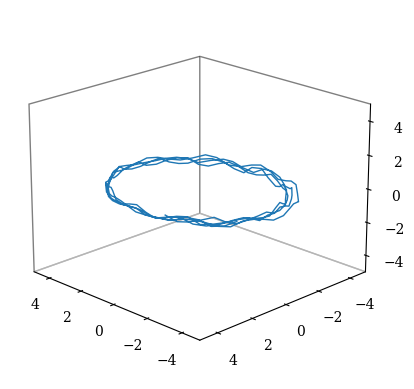

In [10]:
ax = plot_phase_trajectory(PCA(3).fit_transform(np.concatenate(Xs))[:200,:], rotation=(0, 0, 0))
ax.set_xlim(-5,5)
ax.set_ylim(-5,5)
ax.set_zlim(-5,5)

## Init phase space concatenation

In [11]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [12]:
model_1 = InitPhaseAE(x_dims, rank, attractor_dim)
model_1 = fit_torch_model(Xs, model_1)

<Axes3D: >

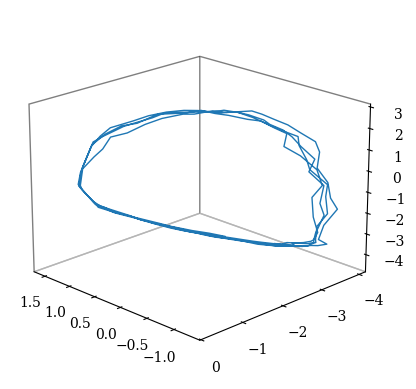

In [13]:
S = model_1.transform(Xs)
plot_phase_trajectory(S[:200,:], rotation=(0, 0, 0),)

## Hidden linear  phase space concatenation

In [14]:
model_2 = HiddenPhaseAE(x_dims, rank, attractor_dim)
model_2 = fit_torch_model(Xs, model_2)

<Axes3D: >

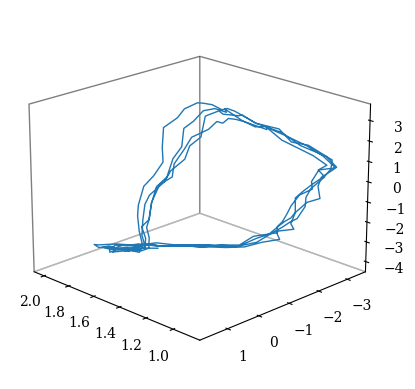

In [15]:
S = model_2.transform(Xs)
plot_phase_trajectory(S[:200,:])

## Hidden multilinear phase space concatenation

In [16]:
model_3 = MultilinearHiddenPhaseAE(x_dims, rank, attractor_dim)
model_3 = fit_torch_model(Xs, model_3)

<Axes3D: >

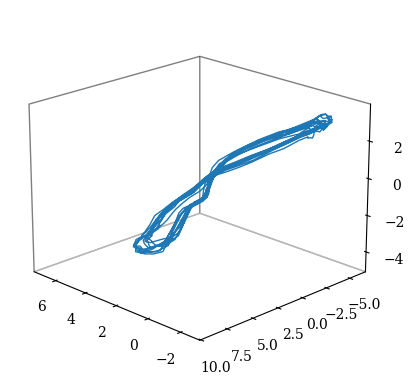

In [17]:
S = model_3.transform(Xs)
plot_phase_trajectory(S[:500,:])

# Experiment over all person

In [18]:
def make_experiment_xy_z(activity, lag):
    result_tables_model_names = [
        'person',
        'Init Phase',
        'Hidden Linear Phase',
        'Hidden Multilinear Phase'
    ] 
    rank = 25
    
    pdf_r2_train_ts = pd.DataFrame(columns=result_tables_model_names)
    pdf_mse_train_ts = pd.DataFrame(columns=result_tables_model_names)
    
    for person in tqdm([3,5,6,9]):
        
        x, y, z = make_ts(person, activity)
        if x.shape[0] <= 650:
            continue
    
        Xs_tde = [
            delay_embedding_matrix(x, lag, fit_intercept=False)[:,::freq_n],
            delay_embedding_matrix(y, lag, fit_intercept=False)[:,::freq_n],
            delay_embedding_matrix(z, lag, fit_intercept=False)[:,::freq_n]
        ]
        x_dims = [x.shape[1] for x in Xs_tde] 
        
        for dim_n in  np.arange(2,7):
            _pdf_r2_train_ts = pd.DataFrame(columns=result_tables_model_names)
            _pdf_mse_train_ts = pd.DataFrame(columns=result_tables_model_names)
    
            # Make state space reconstruction models
            model_init_phase = InitPhaseAE(x_dims, rank, dim_n)
            model_hidden_phase = HiddenPhaseAE(x_dims, rank, dim_n)
            model_tensor_phase = MultilinearHiddenPhaseAE(x_dims, rank, dim_n)
            
            models = [model_init_phase, model_hidden_phase, model_tensor_phase]
            model = [ fit_torch_model(Xs_tde, model) for model in models]
            
            list_S = [model.transform(Xs_tde) for model in models]
            
            list_pred_X = [model.inverse_transform(S) for S, model in zip(list_S, models)]
            
            # Resore initial time series
            xyz_true = np.concatenate(Xs_tde,1)
            xyz_rec = [np.concatenate(X,1) for X in list_pred_X]
            
            
            _pdf_r2_train_ts.loc[dim_n, :] = [person]+[r2_score(xyz_true, xyz) for xyz in xyz_rec]
            _pdf_mse_train_ts.loc[dim_n, :] = [person]+[mse(xyz_true, xyz)**.5 for xyz in xyz_rec]

            pdf_r2_train_ts = pd.concat([pdf_r2_train_ts, _pdf_r2_train_ts], axis=0)
            pdf_mse_train_ts = pd.concat([pdf_mse_train_ts, _pdf_mse_train_ts], axis=0)

    return pdf_r2_train_ts, pdf_mse_train_ts

100%|██████████| 4/4 [02:31<00:00, 37.87s/it]


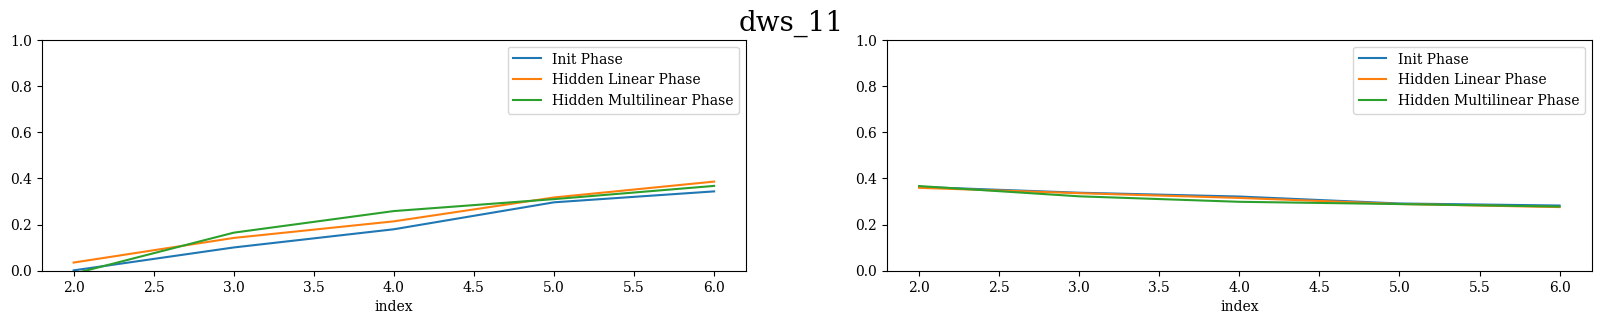

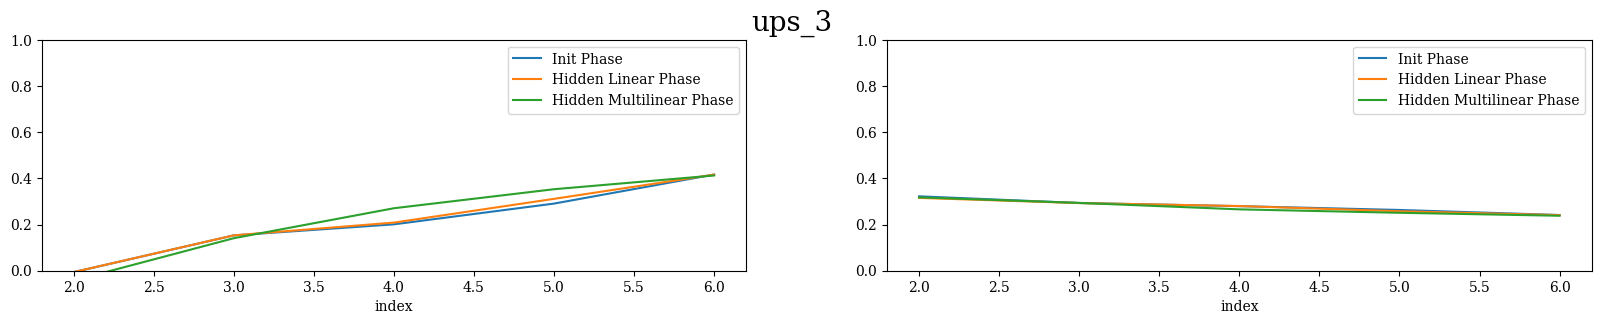

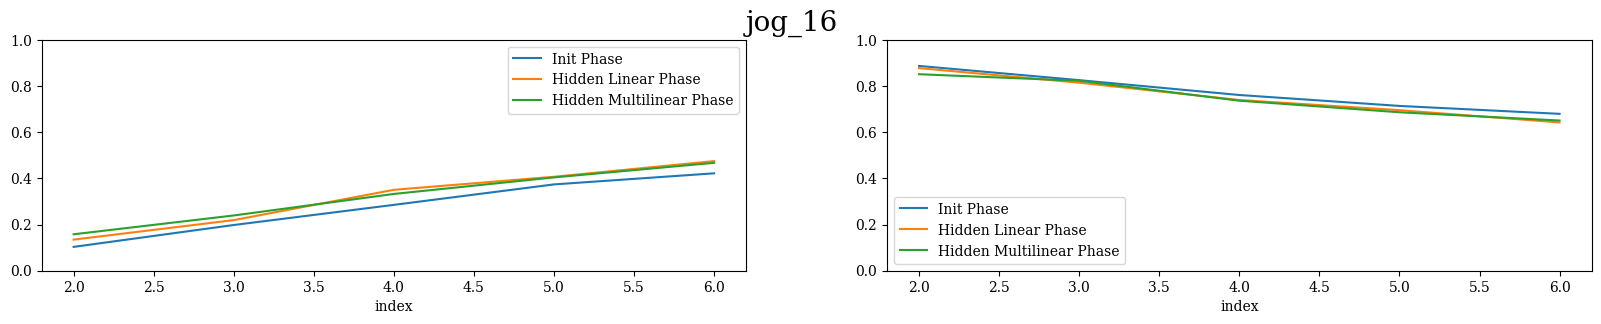

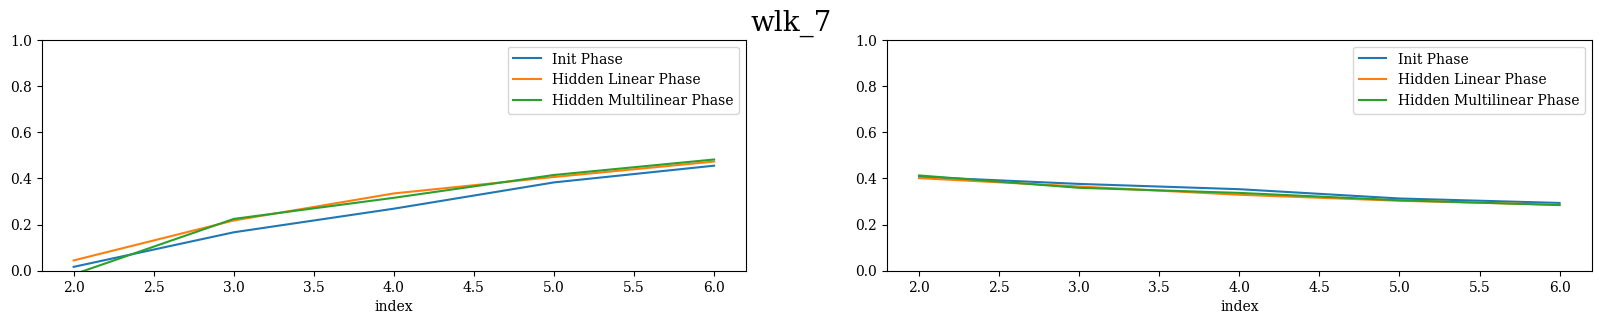

In [19]:
freq_n = 3
list_all_exp = []
list_activities = [
    'dws_11',
    'ups_3',
    # 'wlk_15',
    # 'dws_1', 'dws_2',
    'jog_16',
    # 'jog_9',
    # 'sit_13', 'sit_5',
    # 'std_14', 'std_6',
    # 'ups_12', 'ups_4',
    'wlk_7',
    # 'wlk_8'.
]

list_all_exp = [make_experiment_xy_z(activity, 30) for activity in list_activities]
for name, exp_act in zip(list_activities, list_all_exp):
    fig, axs = plt.subplots(1,2,figsize=(20,3))
    _ = [DF.drop(columns=['person']).reset_index().groupby('index').mean().plot(ax=ax) for DF, ax in zip(exp_act, axs)]
    _ = [ax.set_ylim(0,1) for ax in axs]
    fig.suptitle(name, fontsize=20)

In [20]:
df_r2x, df_msex = [DF.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3) for DF in exp_act]

In [21]:
pdf = list_all_exp[0][0].copy()
pdf['Hidden Linear Phase'] = pdf['Hidden Linear Phase'] - pdf['Init Phase']
pdf['Hidden Multilinear Phase'] = pdf['Hidden Multilinear Phase'] - pdf['Init Phase']
pdf.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3)

,Init Phase,Hidden Linear Phase,Hidden Multilinear Phase
index,,,
2,0.001,0.034,-0.015
3,0.101,0.041,0.064
4,0.179,0.034,0.079
5,0.296,0.021,0.014
6,0.343,0.042,0.024


In [22]:
pdf = list_all_exp[0][1].copy()
pdf['Hidden Linear Phase'] = pdf['Hidden Linear Phase'] - pdf['Init Phase']
pdf['Hidden Multilinear Phase'] = pdf['Hidden Multilinear Phase'] - pdf['Init Phase']
pdf.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3)

,Init Phase,Hidden Linear Phase,Hidden Multilinear Phase
index,,,
2,0.363,-0.004,0.004
3,0.338,-0.002,-0.016
4,0.321,-0.006,-0.023
5,0.291,-0.002,-0.002
6,0.282,-0.007,-0.004


In [23]:
pdf = list_all_exp[1][0].copy()
pdf['Hidden Linear Phase'] = pdf['Hidden Linear Phase'] - pdf['Init Phase']
pdf['Hidden Multilinear Phase'] = pdf['Hidden Multilinear Phase'] - pdf['Init Phase']
pdf.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3)

,Init Phase,Hidden Linear Phase,Hidden Multilinear Phase
index,,,
2,-0.006,0.000,-0.036
3,0.153,0.000,-0.012
4,0.201,0.008,0.070
5,0.291,0.021,0.062
6,0.416,-0.000,-0.004


In [24]:
pdf = list_all_exp[1][1].copy()
pdf['Hidden Linear Phase'] = pdf['Hidden Linear Phase'] - pdf['Init Phase']
pdf['Hidden Multilinear Phase'] = pdf['Hidden Multilinear Phase'] - pdf['Init Phase']
pdf.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3)

,Init Phase,Hidden Linear Phase,Hidden Multilinear Phase
index,,,
2,0.322,-0.007,-0.005
3,0.293,-0.000,0.001
4,0.280,0.000,-0.014
5,0.263,-0.006,-0.012
6,0.241,-0.000,-0.003


In [25]:
exp_act = list_all_exp[0]
df_r2x, df_msex = [DF.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3) for DF in exp_act]
print(' \n'.join(["{} & {} & {} & {} & {} & {} & {} \\\\".format(d,r[0],m[0],r[1],m[1],r[2],m[2])  for d, r, m in zip(df_r2x.index, df_r2x.values, df_msex.values)]))
print()

2 & 0.001 & 0.363 & 0.035 & 0.359 & -0.013 & 0.367 \\ 
3 & 0.101 & 0.338 & 0.142 & 0.336 & 0.165 & 0.322 \\ 
4 & 0.179 & 0.321 & 0.214 & 0.315 & 0.258 & 0.298 \\ 
5 & 0.296 & 0.291 & 0.317 & 0.289 & 0.31 & 0.289 \\ 
6 & 0.343 & 0.282 & 0.386 & 0.275 & 0.367 & 0.278 \\



In [26]:
exp_act = list_all_exp[1]
df_r2x, df_msex = [DF.astype(float).drop(columns=['person']).reset_index().groupby('index').mean().round(3) for DF in exp_act]
print(' \n'.join(["{} & {} & {} & {} & {} & {} & {} \\\\".format(d,r[0],m[0],r[1],m[1],r[2],m[2])  for d, r, m in zip(df_r2x.index, df_r2x.values, df_msex.values)]))
print()

2 & -0.006 & 0.322 & -0.006 & 0.315 & -0.043 & 0.318 \\ 
3 & 0.153 & 0.293 & 0.153 & 0.293 & 0.141 & 0.294 \\ 
4 & 0.201 & 0.28 & 0.208 & 0.28 & 0.27 & 0.266 \\ 
5 & 0.291 & 0.263 & 0.311 & 0.257 & 0.353 & 0.251 \\ 
6 & 0.416 & 0.241 & 0.416 & 0.241 & 0.412 & 0.238 \\

